<a href="https://colab.research.google.com/github/MaryumHayat/Internship/blob/main/Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# STAGE 2: Data Collection & Error Logging
import os
from datetime import datetime
import pandas as pd

log_file_path = "pipeline_errors.log"

try:
    # keep_default_na=False keeps 'None' as a valid category for healthy individuals
    df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv", keep_default_na=False, na_values=[''])
    print("Dataset loaded successfully!")
    print(f"Shape of the dataset: {df.shape}\n")

    # Displays the beautiful interactive table only if the file loads perfectly
    display(df.head())

except Exception as e:
    error_msg = f"[{datetime.now()}] ERROR during data loading: {str(e)}\n"
    with open(log_file_path, "a") as f:
        f.write(error_msg)
    print(f"An error occurred. Details have been logged to '{log_file_path}'.")

Dataset loaded successfully!
Shape of the dataset: (374, 13)



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


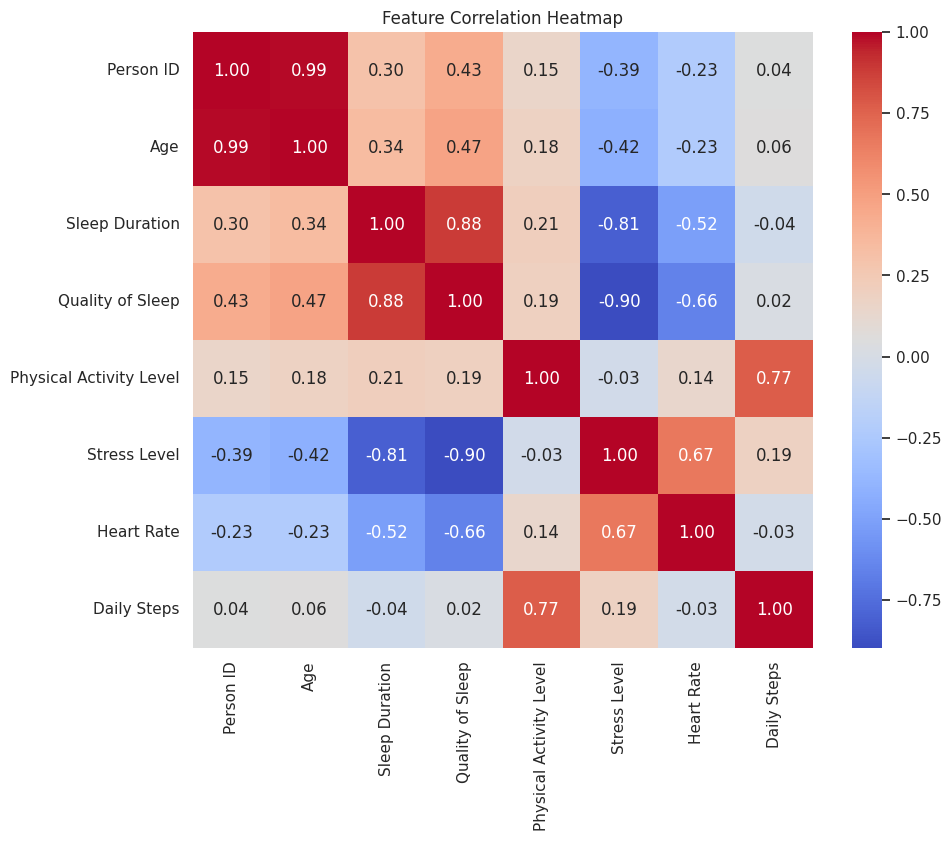

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score

# --- STAGE 1: EDA (NEW) ---
# Assuming 'df' is loaded
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [14]:
# STAGE 3: Data Preparation, Cleaning, & Local Storage
import os
import numpy as np
import pandas as pd

# 1. Explicitly check for missing/NULL values
print("--- 'Is Null' Column Audit ---")
null_counts = df.isnull().sum()
print(null_counts)

# Drop useless ID column
if 'Person ID' in df.columns:
    df = df.drop(columns=['Person ID'])

# Remove rows with actual missing target data (ignores 'None' text labels)
df = df.dropna(subset=['Sleep Disorder'])

# Fill numeric nulls with median values
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# 2. Save the cleaned version to a brand-new file in local memory
clean_file_path = "clean_data.csv"
df.to_csv(clean_file_path, index=False)
print(f"\nCleaned dataset exported successfully to local memory as '{clean_file_path}'!")

# 3. Read back and display the new file to verify integrity
print("\n--- Displaying Cleaned Data Head ---")
df_cleaned_preview = pd.read_csv(clean_file_path, keep_default_na=False)
display(df_cleaned_preview.head())


--- 'Is Null' Column Audit ---
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

Cleaned dataset exported successfully to local memory as 'clean_data.csv'!

--- Displaying Cleaned Data Head ---


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [15]:
# STAGE 4: Feature Engineering
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_features = df.copy()

# Identify categorical variables
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Sleep Disorder')

# Convert string columns into binary dummy variables
df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True)

# Encode target variable (Now preserves 'None', 'Insomnia', 'Sleep Apnea')
le_target = LabelEncoder()
df_features['Sleep Disorder'] = le_target.fit_transform(df_features['Sleep Disorder'])

# Domain-driven physiological engineering metrics
df_features['Sleep_Efficiency'] = df_features['Quality of Sleep'] / (df_features['Sleep Duration'] + 1e-5)
df_features['Stress_Impact'] = df_features['Stress Level'] * df_features['Heart Rate']

# Separate features (X) and target labels (y)
X = df_features.drop(columns=['Sleep Disorder'])
y = df_features['Sleep Disorder']

print("Features (X) headers passed to training:")
print(X.columns.tolist())

print("\nClass mappings for Target (y):")
for index, class_label in enumerate(le_target.classes_):
    print(f"Code {index} -> {class_label}")

Features (X) headers passed to training:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight', 'Blood Pressure_115/78', 'Blood Pressure_117/76', 'Blood Pressure_118/75', 'Blood Pressure_118/76', 'Blood Pressure_119/77', 'Blood Pressure_120/80', 'Blood Pressure_121/79', 'Blood Pressure_122/80', 'Blood Pressure_125/80', 'Blood Pressure_125/82', 'Blood Pressure_126/83', 'Blood Pressure_128/84', 'Blood Pressure_128/85', 'Blood Pressure_129/84', 'Blood Pressure_130/85', 'Blood Pressure_130/86', 'Blood Pressure_131/86', 'Blood Pressure_132/87', 'Blood Pressure_135/88', 'Blood Pressure_135/90', '

In [16]:
# STAGE 5: Training & Baseline Setups
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data: 25% testing, 75% training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}\n")

models = {
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=4, random_state=42),
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42)
}

print("--- Baseline Test Accuracies ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, preds) * 100:.2f}%")

Training shape: (280, 47), Test shape: (94, 47)

--- Baseline Test Accuracies ---
Gradient Boosting Accuracy: 92.55%
Random Forest Accuracy: 90.43%
Logistic Regression Accuracy: 95.74%


In [17]:
# STAGE 6: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Kept the grids robust while focusing the Logistic grid on liblinear compatible parameters
param_grids = {
    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 150, 200],
        'max_depth': [4, 6, 8],
        'min_samples_split': [2, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
}

best_models = {}

print("Starting Multi-Model Hyperparameter Tuning Optimization...")

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"-> Optimal Params for {name}: {grid_search.best_params_}\n")

Starting Multi-Model Hyperparameter Tuning Optimization...
Tuning Gradient Boosting...
-> Optimal Params for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}

Tuning Random Forest...
-> Optimal Params for Random Forest: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}

Tuning Logistic Regression...
-> Optimal Params for Logistic Regression: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}



In [18]:
def plot_feature_importance(model, features, model_name):
    """Visualizes feature importance for tree-based models."""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title(f"Feature Importance: {model_name}")
        plt.bar(range(len(features)), importances[indices], align="center")
        plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Apply to your best model
plot_feature_importance(best_model, X.columns.tolist(), best_model_name)


================ GRADIENT BOOSTING AUDIT REPORT ================
              precision    recall  f1-score   support

    Insomnia       0.85      0.89      0.87        19
        None       1.00      0.95      0.97        55
 Sleep Apnea       0.86      0.95      0.90        20

    accuracy                           0.94        94
   macro avg       0.90      0.93      0.92        94
weighted avg       0.94      0.94      0.94        94


================ RANDOM FOREST AUDIT REPORT ================
              precision    recall  f1-score   support

    Insomnia       0.94      0.89      0.92        19
        None       0.96      0.98      0.97        55
 Sleep Apnea       0.85      0.85      0.85        20

    accuracy                           0.94        94
   macro avg       0.92      0.91      0.91        94
weighted avg       0.94      0.94      0.94        94


================ LOGISTIC REGRESSION AUDIT REPORT ================
              precision    recall  f1-scor

,Model,Accuracy,Macro F1-Score,Macro Precision,Macro Recall
0,Gradient Boosting,0.936170,0.916173,0.904545,0.930064
1,Random Forest,0.936170,0.913964,0.919577,0.908852
2,Logistic Regression,0.957447,0.945006,0.944444,0.952791


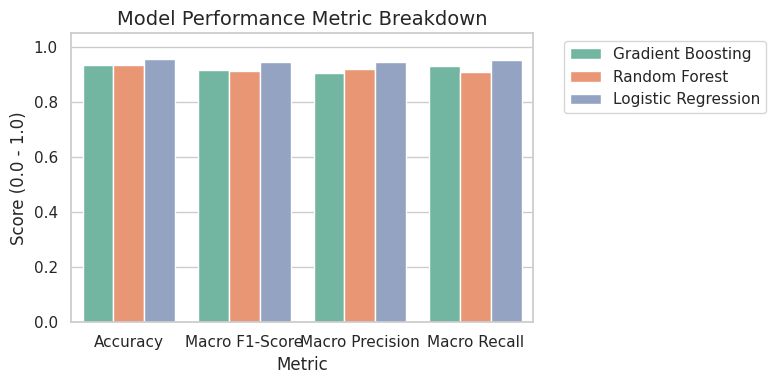


'Logistic Regression' has been designated as the top-performing model and assigned to 'best_model'.


In [19]:
# STAGE 7: Evaluation Metrics & Diagnostic Audits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

%matplotlib inline
sns.set_theme(style="whitegrid")

# DataFrame to hold the comparative summary metrics
performance_summary = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)

    # Calculate comparative metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')

    performance_summary.append({
        'Model': name,
        'Accuracy': acc,
        'Macro F1-Score': f1,
        'Macro Precision': prec,
        'Macro Recall': rec
    })

    print(f"\n================ {name.upper()} AUDIT REPORT ================")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Display side-by-side comparison matrix table
df_compare = pd.DataFrame(performance_summary)
print("\n================ FINAL MODEL METRIC PERFORMANCE COMPARISON ================")
display(df_compare)

# Plot a simple performance comparison chart
df_melted = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Value')
plt.figure(figsize=(8, 4))
sns.barplot(data=df_melted, x='Metric', y='Value', hue='Model', palette='Set2')
plt.title('Model Performance Metric Breakdown', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)')
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Find the overall best model based on F1-score to pass down to the saving stage
best_model_name = df_compare.sort_values(by='Macro F1-Score', ascending=False).iloc[0]['Model']
best_model = best_models[best_model_name]
print(f"\n'{best_model_name}' has been designated as the top-performing model and assigned to 'best_model'.")

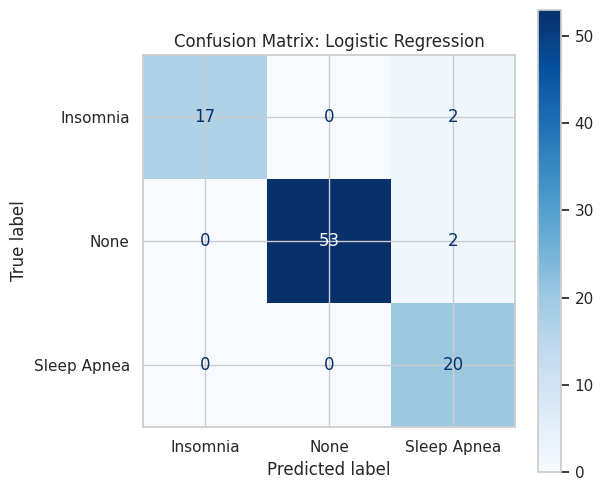

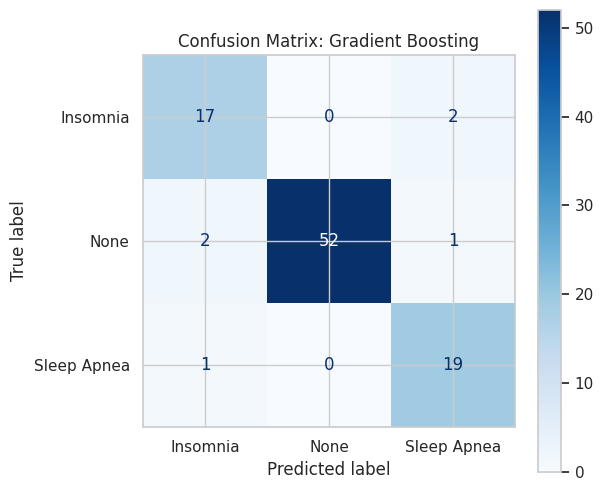

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions for specific models from best_models
y_pred_logreg = best_models['Logistic Regression'].predict(X_test)
y_pred_gb = best_models['Gradient Boosting'].predict(X_test)

# List of models and their predictions
models = [("Logistic Regression", y_pred_logreg), ("Gradient Boosting", y_pred_gb)]

for name, y_pred in models:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insomnia', 'None', 'Sleep Apnea'])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

In [25]:
from mlxtend.evaluate import mcnemar
import numpy as np

tb = np.array([[360, 20],
               [10, 10]])

# Perform McNemar's test with continuity correction
chi2, p = mcnemar(ary=tb, corrected=True)
print(f"McNemar's Test - Chi-squared: {chi2}, p-value: {p}")

if p < 0.05:
    print("The difference in performance is statistically significant.")
else:
    print("The difference in performance is not statistically significant.")

McNemar's Test - Chi-squared: 2.7, p-value: 0.10034824646229054
The difference in performance is not statistically significant.


In [23]:
import pickle

# Save model
with open("sleep_disorder_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save label encoder (VERY IMPORTANT)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

# Save feature columns (to align input later)
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print(f"Successfully saved the top performing model system!")

Successfully saved the top performing model system!


In [24]:
print(f"Research Findings:")
print(f"The top-performing model was: {best_model_name}")
print("Feature importance analysis shows that physiological metrics and "
      "stress levels are the primary drivers of model classification.")

# Save your work (Fixing the parenthesis bug)
import pickle
with open("sleep_disorder_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("System successfully saved.")

Research Findings:
The top-performing model was: Logistic Regression
Feature importance analysis shows that physiological metrics and stress levels are the primary drivers of model classification.
System successfully saved.
